### Imports

In [3]:
from jax import numpy as jnp
from jax import scipy as jsp
from jax import random
import jax

from matplotlib import pyplot as plt
import matplotlib

import equinox as eqx

import optax

from tqdm.notebook import tqdm

import riemannian_dynamics as rd
from riemannian_dynamics.plotting import plotting2d, plotting3d, utils

from riemannian_dynamics.static.mlp import MLP

from functools import partial

utils.set_font(font_size=18)

jax.config.update('jax_platforms', 'cpu')
jax.config.update("jax_default_device", jax.devices('cpu')[0])

In [4]:
cmap_manifold = utils.get_cmap_interpolated(*matplotlib.colormaps['YlGnBu'](jnp.linspace(0, 1, 101)),
                                            *matplotlib.colormaps['YlGnBu_r'](jnp.linspace(0, 1, 101)),
                                            *matplotlib.colormaps['YlOrRd'](jnp.linspace(0, 1, 101)),
                                            *matplotlib.colormaps['YlOrRd_r'](jnp.linspace(0, 1, 101)))

### Input definition

In [5]:
mesh_size = 241

thetas = jnp.linspace(0, jnp.pi*2, mesh_size)[:-1]
input_embedding = lambda theta: jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=-1)

xs = jax.vmap(input_embedding)(thetas)

ticks = lambda x, nb_ticks: x[:-1:x.shape[0]//nb_ticks]

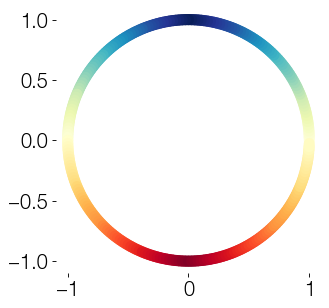

In [6]:
axs, gs, fig = rd.plotting.utils.get_ax_gridspec(1, 1)

# ===== Input circle =====
plotting2d.plot_with_gradient_2d(axs[0, 0], xs[..., 0], xs[..., 1], thetas/(jnp.pi*2), cmap=cmap_manifold, set_lim=True, linewidth=10.0)

utils.remove_axes(axs[0, 0])
axs[0, 0].set_xlim(-1.1, 1.1)
axs[0, 0].set_ylim(-1.1, 1.1)
axs[0, 0].set_aspect('equal')

plt.show()

### Network definition

In [17]:

# Define network parameters
input_dim = xs.shape[-1]  # Based on xs.shape[-1]
output_dim = 1 # Example output dimension
hidden_width = 3 # Example hidden layer width
hidden_depth = 1  # Example number of hidden layers (total layers = depth + 1)
activation_fn = jax.nn.tanh # As requested
output_regions = 1

# Create a JAX PRNG key
key = random.PRNGKey(0)
model_key, data_key = jax.random.split(key)

# Instantiate the model
model = MLP(in_size=input_dim,
            out_size=output_dim,
            width_size=hidden_width,
            depth=hidden_depth,
            activation=activation_fn,
            key=model_key)

### Training

In [18]:
training_iterations = 0
learning_rate = 0.01

optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

def target_output(theta):

    return (jnp.mod(theta, jnp.pi*2/output_regions) < (0.5*jnp.pi*2/output_regions))*2.0 - 1
    #return jnp.tanh(2.0*jnp.sin(theta))

def loss(model, theta, key):
    y = target_output(theta)
    #y = jnp.tanh((theta-jnp.pi)*5)
    return jnp.mean((model(input_embedding(theta), key) - y) ** 2)

def mean_loss(model, thetas, keys):

    return jax.vmap(loss, in_axes=(None, 0, 0))(model, thetas, keys).mean()

iterator = tqdm(range(training_iterations))

ls = []

for iteration in iterator:

    theta_mask = jnp.ones(thetas.shape, dtype=bool)#[(thetas>jnp.pi/2)&(thetas<3*jnp.pi/2)]

    # Compute gradients
    key, subkey = random.split(key)
    subkeys = random.split(subkey, theta_mask.astype(int).sum())
    l_train, grads = eqx.filter_value_and_grad(mean_loss)(model, thetas[theta_mask], subkeys)

    # Update parameters using optimizer
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)

    l_test = jax.vmap(loss, in_axes=(None, 0, None))(model, thetas, None).mean()
    iterator.set_description(f'Loss: {l_test:.3f}')

    ls.append([l_train, l_test])

ls = jnp.array(ls)

0it [00:00, ?it/s]

In [19]:
input_embedding_mlp = lambda theta, i: model.get_activity(input_embedding(theta), i)

### Plotting

Layer 1: Singular values: [7.238379   3.747863   0.10776956]


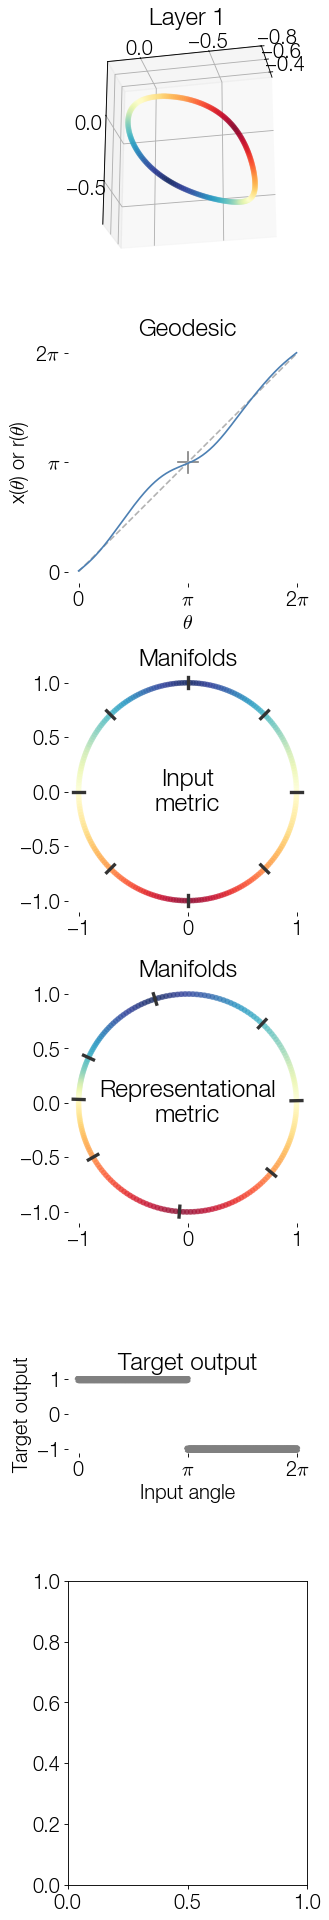

In [24]:
axs, gs, fig = rd.plotting.utils.get_ax_gridspec(6, hidden_depth, rows_3d=(0,), dpi=80)

for i, ax_ in enumerate(axs):

    dtheta = jax.vmap(jax.jacrev(input_embedding))(thetas)

    dr_dtheta = jax.vmap(jax.jacrev(lambda theta: input_embedding_mlp(theta, i)))(thetas)

    rs = eqx.filter_vmap(input_embedding_mlp, in_axes=(0, None))(thetas, i)

    ax = ax_[0]
    plotting3d.plot_with_gradient_3d(ax, *jnp.concatenate([rs, rs[:1]]).T, cmap=cmap_manifold, gradient=thetas/(jnp.pi*2), linewidth=5.0, alpha=0.5, set_lim=False)

    #rs_ = rs.at[..., 1].set(jnp.min(rs)-(jnp.max(rs)-jnp.min(rs))*0.1)
    #plotting3d.plot_with_gradient_3d(ax, *jnp.concatenate([rs_, rs_[:1]]).T, cmap=cmap_manifold, gradient=thetas/(jnp.pi*2), linewidth=5.0, alpha=0.5, set_lim=False)

    ax.set_xlim(jnp.min(rs[..., 0])-0.1*(jnp.max(rs[..., 0]) - jnp.min(rs[..., 0])), jnp.max(rs[..., 0])+0.1*(jnp.max(rs[..., 0]) - jnp.min(rs[..., 0])))
    ax.set_ylim(jnp.min(rs[..., 1])-0.1*(jnp.max(rs[..., 1]) - jnp.min(rs[..., 1])), jnp.max(rs[..., 1])+0.1*(jnp.max(rs[..., 1]) - jnp.min(rs[..., 1])))
    ax.set_zlim(jnp.min(rs[..., 2])-0.1*(jnp.max(rs[..., 2]) - jnp.min(rs[..., 2])), jnp.max(rs[..., 2])+0.1*(jnp.max(rs[..., 2]) - jnp.min(rs[..., 2])))
    ax.set_aspect('equal')
    ax.set_title(f'Layer {i+1}')

    _, S, V = jnp.linalg.svd(rs - rs.mean(axis=0), full_matrices=False)
    utils.set_view_for_plane(ax, V[0], V[1])

    #plotting3d.plot_vector_fields(ax, rs[::mesh_size//20, None], dr_dtheta[None, ::mesh_size//20, None]*5)

    # ===== geodesic length =====
    ax = ax_[1]

    dtheta_dtheta = jnp.mod(thetas - jnp.roll(thetas, 1), jnp.pi*2)
    geodesic = jnp.cumsum(jnp.linalg.norm(dr_dtheta, axis=-1)*dtheta_dtheta, axis=0)
    geodesic = jnp.pi*2*geodesic/geodesic[-1]

    ax.plot(thetas, thetas, linestyle='--', color=(0.7, 0.7, 0.7), label='Input geodesic', zorder=5)
    ax.plot(thetas, geodesic, color=(0.3, 0.5, 0.7), label='Representational geodesic', zorder=6)

    ax.plot([jnp.pi, jnp.pi], [jnp.pi-0.3, jnp.pi+0.3], color=(0.5, 0.5, 0.5), zorder=4)
    ax.plot([jnp.pi-0.3, jnp.pi+0.3], [jnp.pi, jnp.pi], color=(0.5, 0.5, 0.5), zorder=4)

    ax.set_xticks([0, jnp.pi, jnp.pi*2], ['$0$', r'$\pi$', r'$2\pi$']), ax.set_yticks([0, jnp.pi, jnp.pi*2], ['$0$', r'$\pi$', r'$2\pi$'])
    ax.set_aspect('equal')
    utils.remove_axes(ax)

    ax.set_xlabel(r'$\theta$'), ax.set_ylabel(r'$x(\theta)$ or $r(\theta)$')

    #ax.legend()

    ax.set_title('Geodesic')

    # ===== gridlines =====
    xs_hat = jax.vmap(input_embedding)(geodesic)

    for ax, x, l in zip(ax_[2:4], [xs, xs_hat], ['Input\nmetric', 'Representational\nmetric']):

        plotting3d.plot_with_gradient_2d(ax, *jnp.concatenate([x, x[:1]]).T, cmap=cmap_manifold, gradient=thetas/(jnp.pi*2), linewidth=5.0, alpha=0.5)

        x_ticks = ticks(x, 8)
        ax.plot(*jnp.stack([x_ticks*0.95, x_ticks*1.05], axis=1).transpose(2, 1, 0), zorder=6, color=3*[0.2], linewidth=3.0, alpha=1.0)

        utils.remove_axes(ax)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal')

        ax.text(0.0, 0.0, l, va='center', ha='center', fontsize=22)

        ax.set_title('Manifolds')

    # ===== target =====
    ax = ax_[4]

    ax.scatter(thetas, target_output(thetas), color=(0.5, 0.5, 0.5), linestyle='--', label='Target')
    ax.set_xticks([0, jnp.pi, jnp.pi*2], ['$0$', r'$\pi$', r'$2\pi$']), ax.set_yticks([-1, 0, 1])
    ax.set_xlabel('Input angle'), ax.set_ylabel('Target output')

    ax.set_title('Target output')

    ax.set_aspect('equal')

    utils.remove_axes(ax)

    # ===== target =====
    ax = ax_[5]

    if len(ls)>0:
        ax.plot(ls[:, 0], label='Train')
        ax.plot(ls[:, 1], label='Test')

        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss (MSE)')
        ax.legend()
        ax.set_title('Loss')

        utils.remove_axes(ax)
        ax.set_aspect(len(ls)/(jnp.max(ls)-jnp.min(ls)))

plt.savefig('./plots/metric_.pdf')